In [21]:
"""
Created on Mon Jul 21 19:53:19 2025

@author: huzefa
"""

'\nCreated on Mon Jul 21 19:53:19 2025\n\n@author: huzefa\n'

In [22]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn import cluster
from sklearn.preprocessing import StandardScaler
import copy as cp

In [23]:
#Reading data
data=pd.read_excel('../Datasets/tripDetails.xlsx')
print(data.head())

   TripID  TripLength  MaxSpeed  MostFreqSpeed  TripDuration  Brakes  \
0       1          21        51             14            93     307   
1       2         148       130            106           156     226   
2       3          18        38             16           100     351   
3       4          22        43             48            36      17   
4       5         183       108             90           171      88   

   IdlingTime  Honking  
0          27      112  
1           5      114  
2          26      107  
3           4        5  
4           5       29  


In [24]:
#Dropping TripID column
data=data.drop(['TripID'],axis=1)
print(data.head())

   TripLength  MaxSpeed  MostFreqSpeed  TripDuration  Brakes  IdlingTime  \
0          21        51             14            93     307          27   
1         148       130            106           156     226           5   
2          18        38             16           100     351          26   
3          22        43             48            36      17           4   
4         183       108             90           171      88           5   

   Honking  
0      112  
1      114  
2      107  
3        5  
4       29  


In [25]:
#Taking column name as features
features=list(data.columns)

In [26]:
#Creating a new dataframe for units of the data columns
units=['kms','kmph','kmps','mins','counts','mins','counts']

In [27]:
#Mapping features to units
feature_units=dict(zip(features,units))
print(feature_units)

{'TripLength': 'kms', 'MaxSpeed': 'kmph', 'MostFreqSpeed': 'kmps', 'TripDuration': 'mins', 'Brakes': 'counts', 'IdlingTime': 'mins', 'Honking': 'counts'}


In [28]:
#Data types of variables
data.info()
data.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 91 entries, 0 to 90
Data columns (total 7 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   TripLength     91 non-null     int64
 1   MaxSpeed       91 non-null     int64
 2   MostFreqSpeed  91 non-null     int64
 3   TripDuration   91 non-null     int64
 4   Brakes         91 non-null     int64
 5   IdlingTime     91 non-null     int64
 6   Honking        91 non-null     int64
dtypes: int64(7)
memory usage: 5.1 KB


,TripLength,MaxSpeed,MostFreqSpeed,TripDuration,Brakes,IdlingTime,Honking
count,91.000000,91.000000,91.000000,91.000000,91.000000,91.000000,91.000000
mean,70.769231,70.362637,50.648352,87.373626,135.439560,11.593407,49.923077
std,73.302126,34.509424,34.349632,47.123160,114.758607,9.796800,46.371023
min,16.000000,35.000000,12.000000,22.000000,14.000000,4.000000,4.000000
25%,20.000000,42.000000,15.500000,34.500000,36.500000,5.000000,20.000000
50%,21.000000,54.000000,42.000000,88.000000,100.000000,5.000000,25.000000
75%,163.000000,105.500000,89.000000,133.000000,198.000000,24.000000,97.500000
max,210.000000,138.000000,118.000000,171.000000,429.000000,32.000000,155.000000


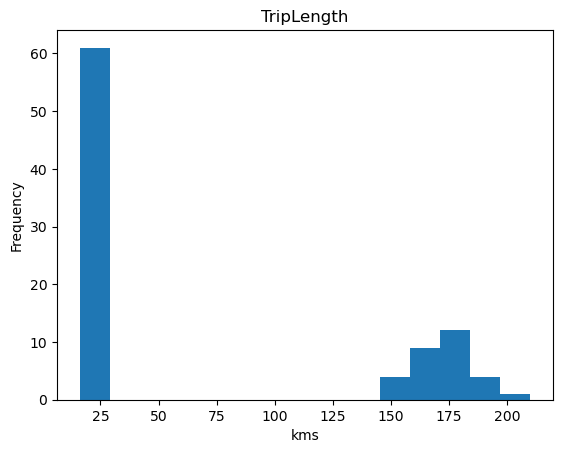

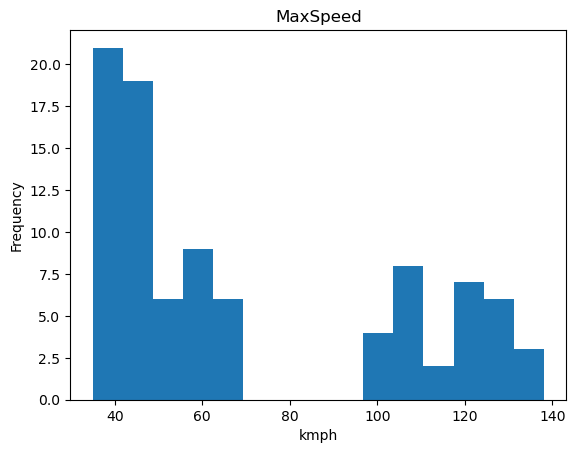

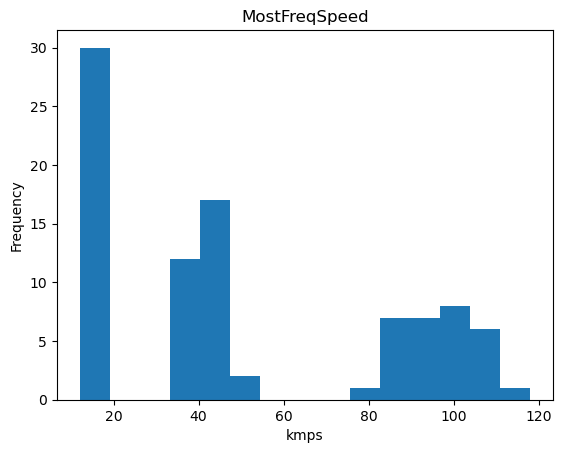

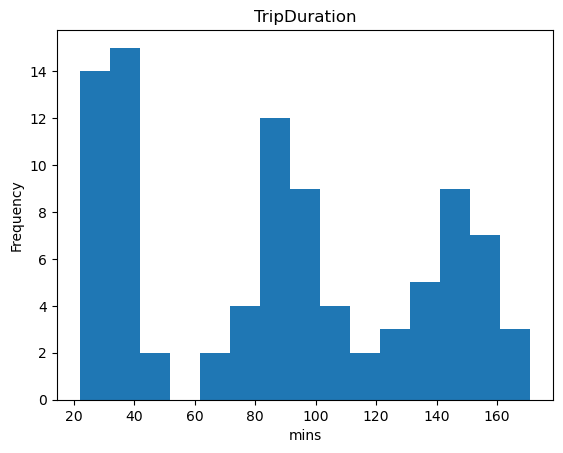

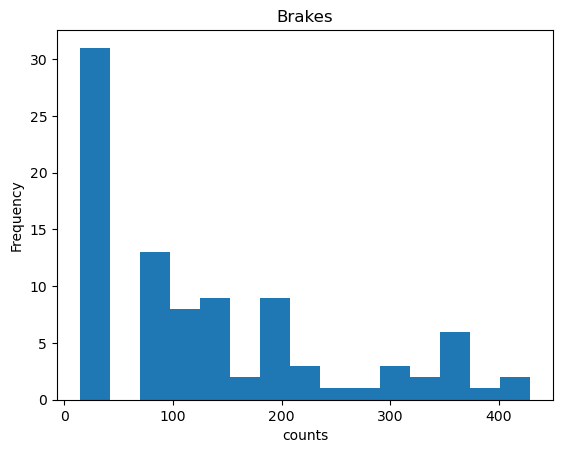

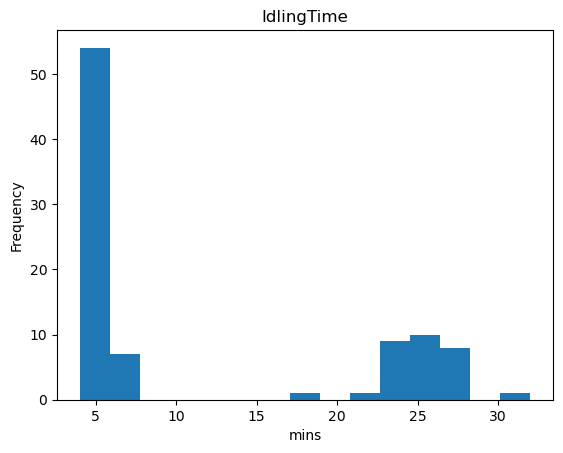

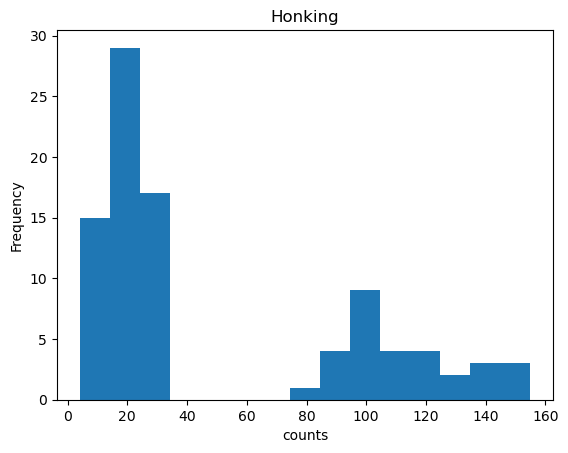

In [29]:
#Histogram of each features
for i in features:
    data[i].plot(kind='hist', bins=15)
    plt.title(i)
    plt.xlabel(feature_units[i])
    plt.show()

In [30]:
#Checking relationships between different features
correlation=data.corr()
print(correlation)

               TripLength  MaxSpeed  MostFreqSpeed  TripDuration    Brakes  \
TripLength       1.000000  0.933549       0.922928      0.842934  0.047158   
MaxSpeed         0.933549  1.000000       0.928592      0.730388  0.011993   
MostFreqSpeed    0.922928  0.928592       1.000000      0.632675 -0.182159   
TripDuration     0.842934  0.730388       0.632675      1.000000  0.416028   
Brakes           0.047158  0.011993      -0.182159      0.416028  1.000000   
IdlingTime      -0.471204 -0.564379      -0.726001      0.018913  0.641201   
Honking          0.429318  0.458151       0.309691      0.571365  0.778774   

               IdlingTime   Honking  
TripLength      -0.471204  0.429318  
MaxSpeed        -0.564379  0.458151  
MostFreqSpeed   -0.726001  0.309691  
TripDuration     0.018913  0.571365  
Brakes           0.641201  0.778774  
IdlingTime       1.000000  0.160450  
Honking          0.160450  1.000000  


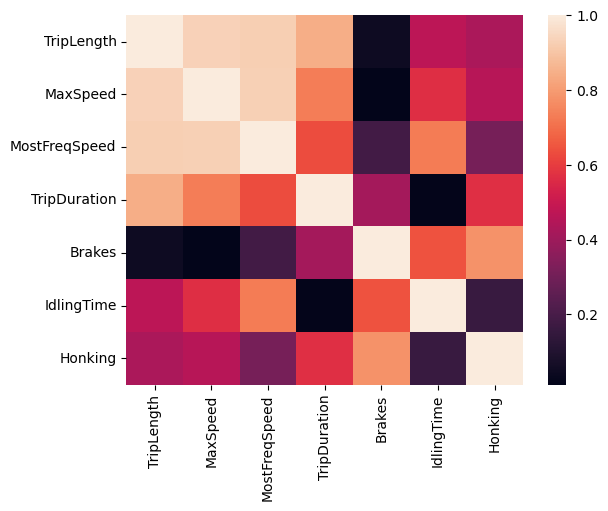

In [31]:
#Visualizing correlation using heatmaps
sns.heatmap(np.abs(correlation), xticklabels=correlation.columns,yticklabels=correlation.columns)
plt.show()

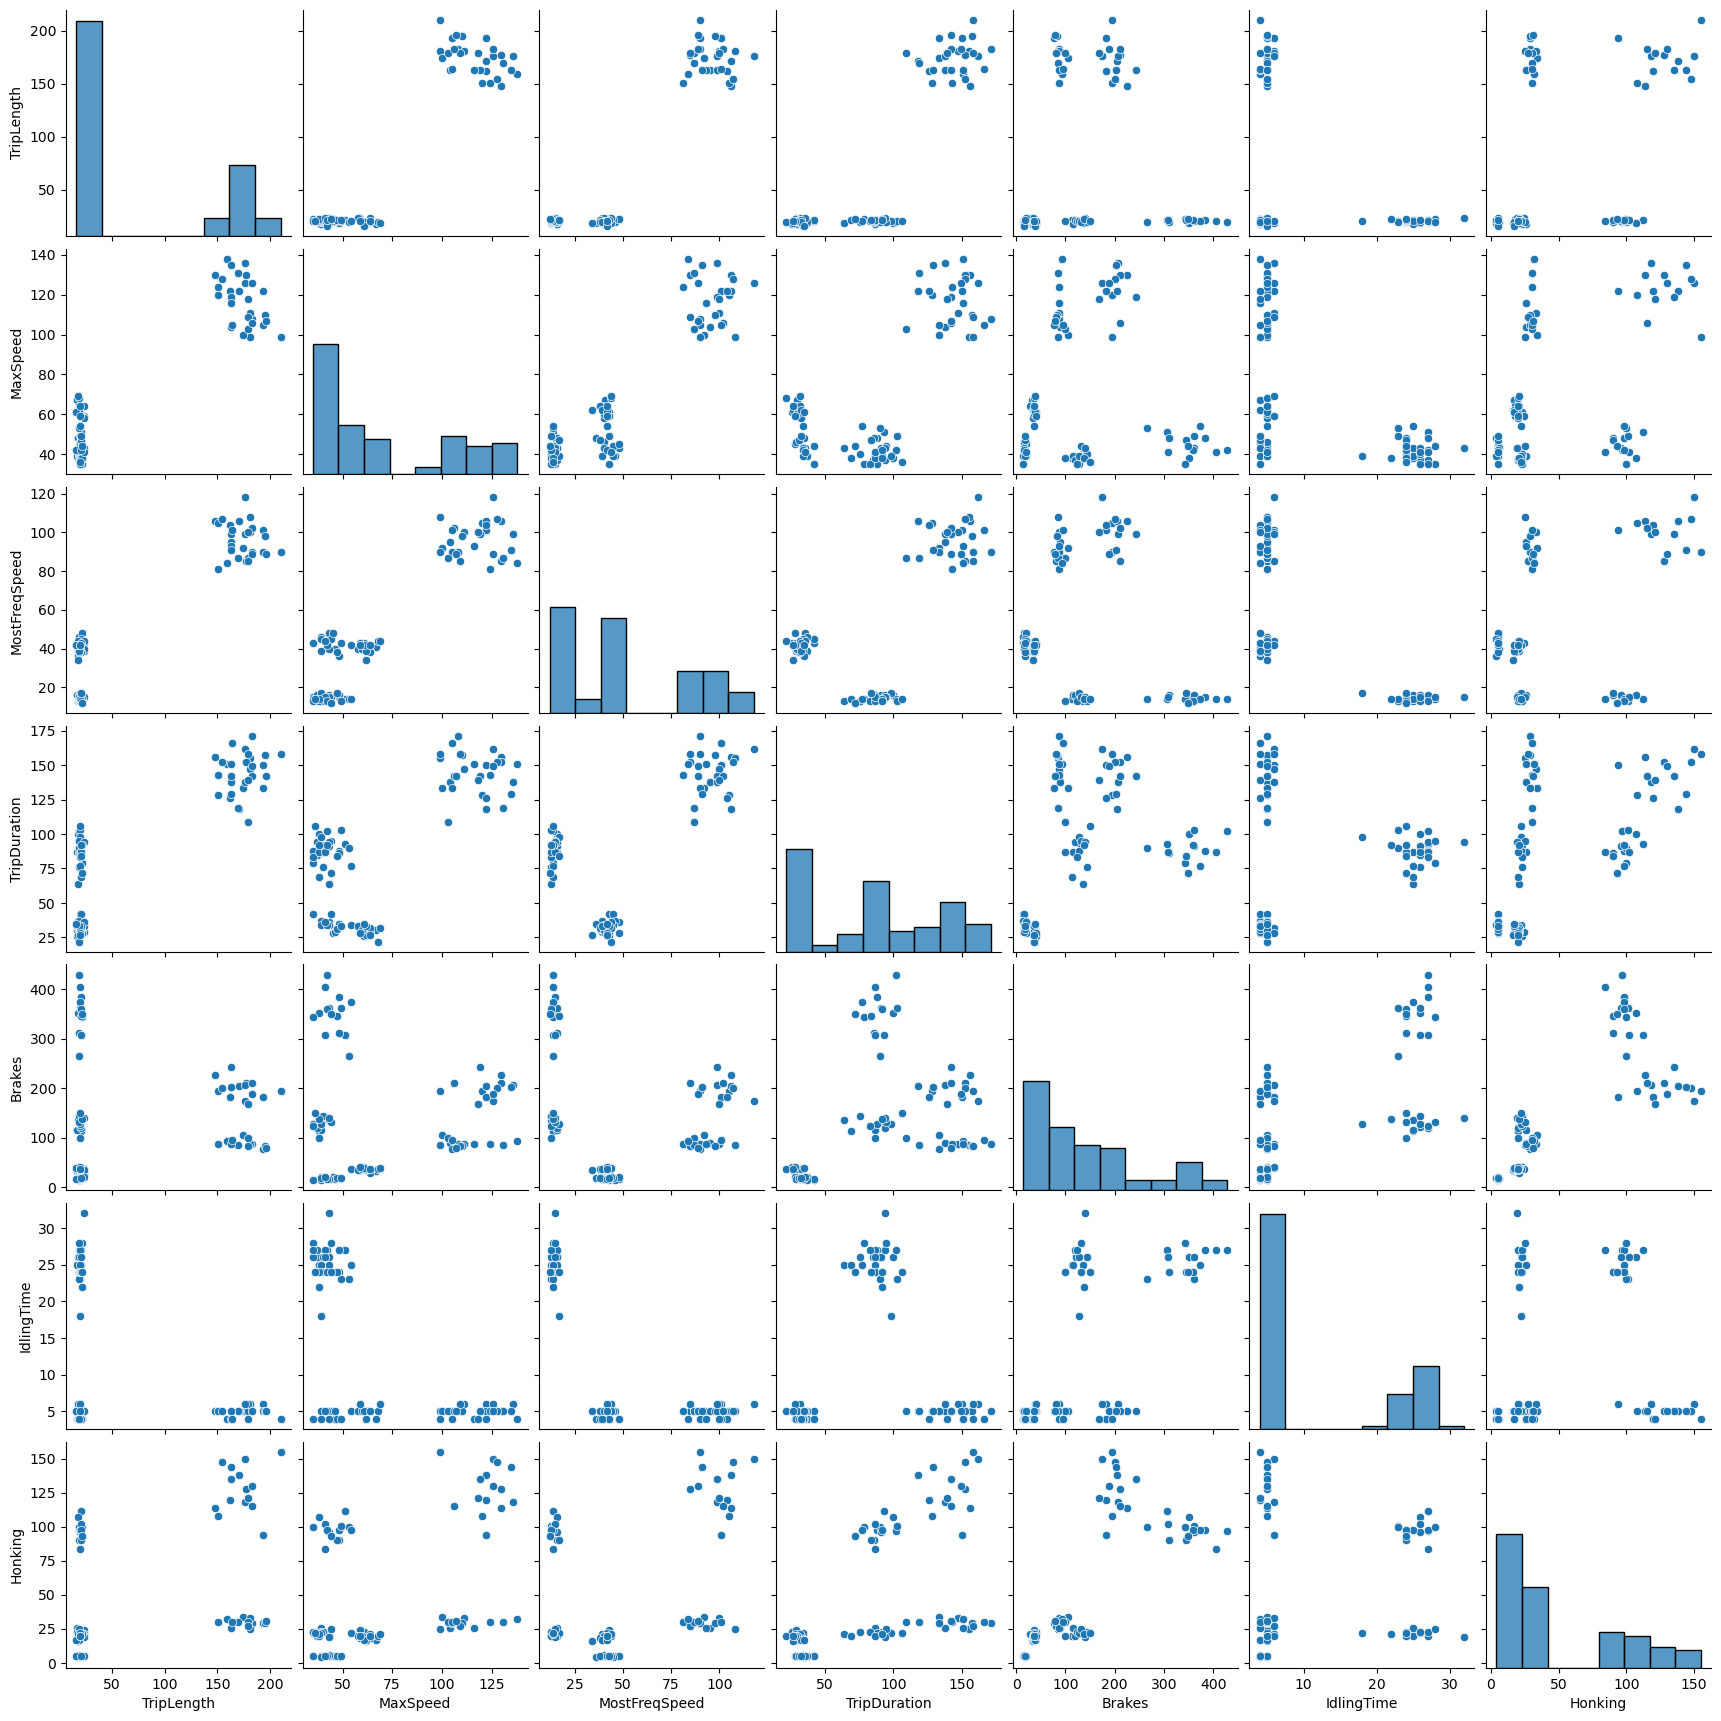

In [32]:
#Visualizing scatter data
sns.pairplot(data)
plt.show()

In [33]:
#Now scaling all the values to same level
data2=data.copy()
data2=StandardScaler().fit_transform(data2.values)
data2=pd.DataFrame(data2,columns=features)

In [34]:
#Applying k-means clustering for different sequential values and plotting an elbow plot to get the most optimum k value
distortions=[]
for i in range(1,11):
    km=cluster.KMeans(n_clusters=i,init='k-means++',n_init=10,max_iter=300,random_state=100)
    km.fit(data2.values)
    distortions.append(km.inertia_)

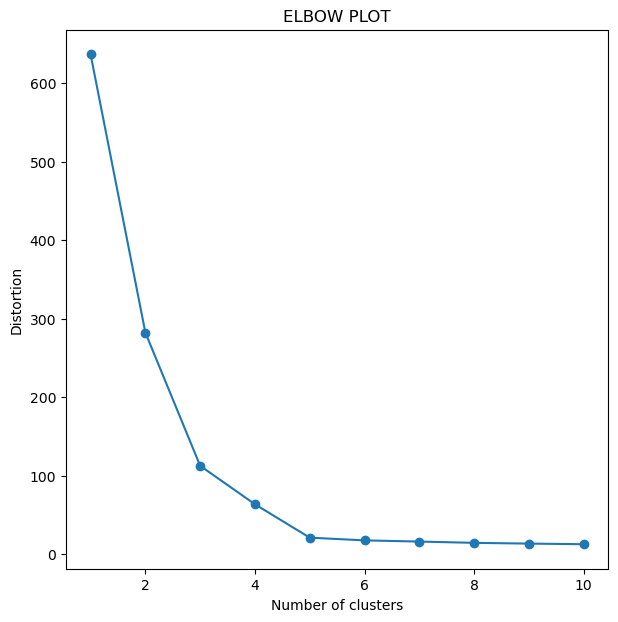

In [35]:
plt.figure(figsize = (7,7))
plt.plot(range(1,11), distortions, marker='o')
plt.title('ELBOW PLOT')
plt.xlabel('Number of clusters')
plt.ylabel('Distortion')
plt.show()

In [36]:
#Taking k=3 is best value obtained
k = 3
km3 = cluster.KMeans(n_clusters=k,
init='k-means++',
n_init = 10,
max_iter = 300,
random_state = 100)
km3.fit(data2.values)

KMeans(n_clusters=3, n_init=10, random_state=100)

In [37]:
#Obtaining lables for each row to map to their clusters respectively
labels = km3.labels_
Ccenters = km3.cluster_centers_
data2['labels'] = labels
data2['labels'] = data2['labels'].astype('str')
print(data2['labels'])

0     2
1     1
2     2
3     0
4     1
     ..
86    2
87    1
88    2
89    1
90    0
Name: labels, Length: 91, dtype: object


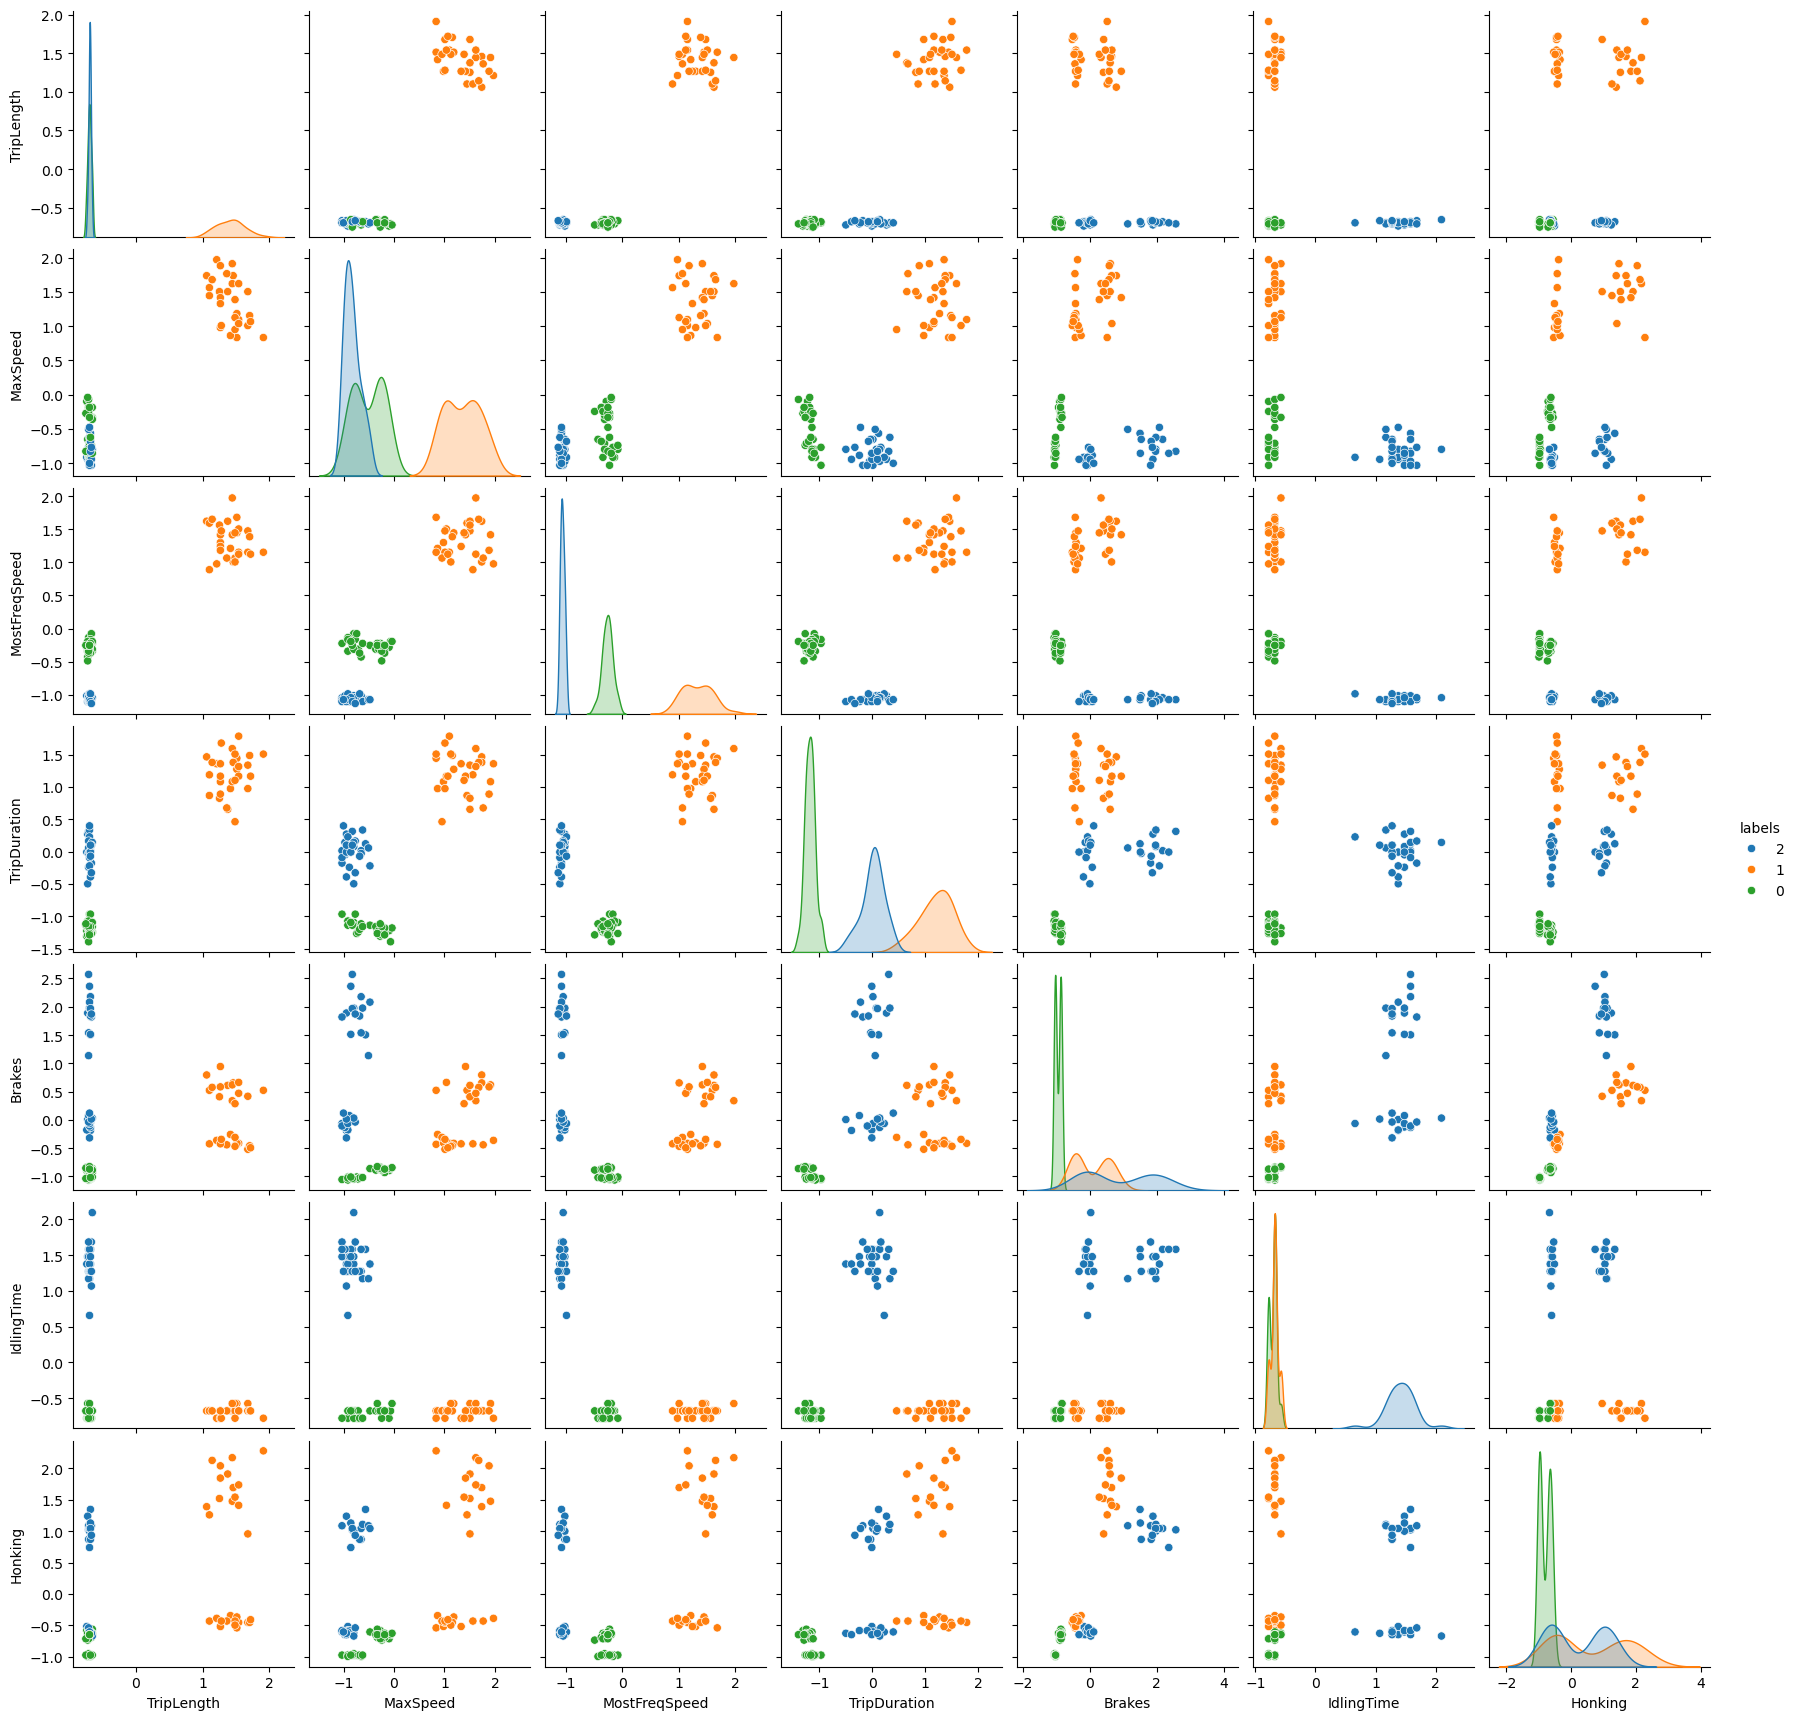

In [38]:
#Pairplot after clustering
sns.pairplot(data2, x_vars = features, y_vars = features, hue='labels', diag_kind='kde')
plt.show()

In [39]:
#Clusterwise feature analysis using original data
c_df = pd.concat([data[data2['labels']=='0'].mean(),
data[data2['labels']=='1'].mean(),
data[data2['labels']=='2'].mean()],
axis=1)
c_df.columns = ['cluster1','cluster2','cluster3']
print(c_df)

                cluster1    cluster2    cluster3
TripLength     19.838710  174.000000   20.166667
MaxSpeed       52.806452  116.966667   41.900000
MostFreqSpeed  41.677419   96.066667   14.500000
TripDuration   32.129032  143.800000   88.033333
Brakes         27.161290  143.866667  238.900000
IdlingTime      4.709677    4.966667   25.333333
Honking        12.516129   78.633333   59.866667


In [40]:
#Using obtained instights about clusters, it can be infered that the clusters may belong to following practical categories
'''
Cluster1 is indicative of city trips during non-peak hours

MaxSpeed, MostFreqSpeed and TripDuration is higher for cluster2 than cluster
1 and 3
Cluster2 is is indicative of highway trips

Cluster3 is distinguised by comparatively very high values for Brakes,
IdlingTime, Honking, low MaxSpeed and TripLength
This is indicative of intercity travel during peak hours
''' 
#Assigning the names to clusters
triptype = ['Intercity-Non-peak hours','Highway','Intercity-Peak hours']
data['labels'] = labels
data['labels'] = data['labels'].map({0:triptype[0],1:triptype[1],2:triptype[2]})
print(data.head())

   TripLength  MaxSpeed  MostFreqSpeed  TripDuration  Brakes  IdlingTime  \
0          21        51             14            93     307          27   
1         148       130            106           156     226           5   
2          18        38             16           100     351          26   
3          22        43             48            36      17           4   
4         183       108             90           171      88           5   

   Honking                    labels  
0      112      Intercity-Peak hours  
1      114                   Highway  
2      107      Intercity-Peak hours  
3        5  Intercity-Non-peak hours  
4       29                   Highway  
